<img src="../../supervised_learning/holberton_logo.png" alt="logo" width="500"/>

# Exploring Clustering through IRIS dataset

## Project Goal

The goal of this project is to apply `K-Means` clustering to the `IRIS` dataset to discover underlying patterns and group similar observations together based on their features. By doing so, we aim to achieve several objectives:

1. **Unsupervised Learning**: Apply unsupervised learning techniques to the IRIS dataset, which is a well-known dataset in machine learning, to explore its inherent structure without relying on labeled target variables.


2. **Cluster Identification**: Identify natural groupings or clusters within the dataset. In the case of the IRIS dataset, we expect to discover clusters that represent different species of iris flowers.


3. **Data Exploration and Visualization**: Gain insights into the characteristics of the iris flowers and how they differ from one another based on their feature attributes, such as sepal length, sepal width, petal length, and petal width. Visualize the results of the clustering analysis to make it easier to interpret and understand the structure of the dataset.


## Importing the Necessary Libraries

In this step, we bring in essential Python libraries such as

- `NumPy` for numerical operations


- `Pandas` for data manipulation


- `Matplotlib` and `Seaborn` for data visualization


- `scikit-learn` to apply the K-Means clustering algorithm, evaluate clustering performance, and split the dataset into training and testing sets


- `scipy` to perform statistical analysis and calculate evaluation metrics for clustering quality


- `KElbowVisualizer` to visualize the elbow method for selecting the optimal number of clusters in K-Means.


These libraries provide the foundation for data exploration and dimensionality reduction in subsequent steps.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from scipy.spatial.distance import cdist

from yellowbrick.cluster import KElbowVisualizer


sns.set(style='whitegrid')

## Load and Explore the IRIS Dataset

The goal is to **prepare and familiarize** ourselves **with the `Iris` dataset**.


In this step, we load the dataset, inspect its structure using functions like `head()`, `info()`, and `describe()`, and create visualizations such as pair plots, histograms, and box plots to gain a comprehensive understanding of the dataset's characteristics.

This exploration is crucial for identifying any data issues, patterns, or insights that will inform subsequent analysis, including dimensionality reduction using `PCA` and `t-SNE`

In [2]:
# Load and Explore Iris Dataset

from sklearn.datasets import load_iris
data = load_iris()

iris_df = pd.DataFrame(data.data, columns=data.feature_names)

print("First few rows of the Iris dataset:")
print(iris_df.head())

print("\nInformation about the Iris dataset:")
print(iris_df.info())

print("\nSummary statistics of the Iris dataset:")
print(iris_df.describe())

First few rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Information about the Iris dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Summary statistics of the Iris da

## Exploring the Dataset

Our goal is to visualize the characteristics of the the Iris dataset. To do so, we add a `species` column with mapped species names to the dataset and then genarete a pair plot matrix.

The pair plot visually represents the relationships between different pairs of features, while coloring the data points according to their corresponding species labels, aiding in the exploration of the dataset's underlying patterns and distinctions between iris species.

C:\Users\evisp\anaconda3\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


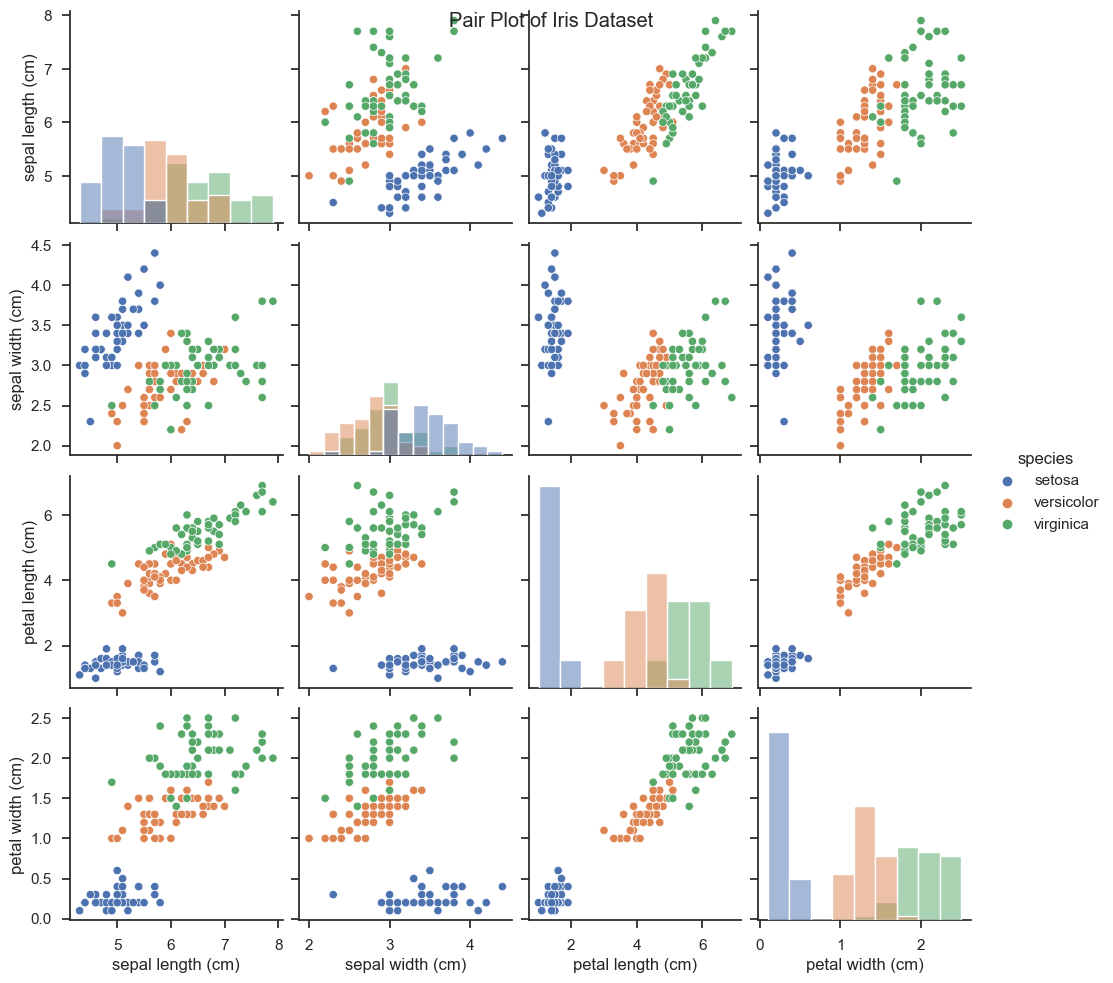

In [3]:
# Visualize the dataset characteristics using pair plots, histograms, and box plots
iris_df['species'] = data.target
iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Visualize the dataset characteristics using pair plots with mapped labels
sns.set(style="ticks")
pair_plot = sns.pairplot(iris_df, hue='species', diag_kind='hist')
plt.suptitle("Pair Plot of Iris Dataset")
plt.show()

### Exploring  Petal and Sepal Dimensions

We generate a scatter plot of sepal length versus sepal width for the Iris dataset, where the data points are color-coded according to their species labels. Similarly, we also create a scatter plot, but this time it's for petal length versus petal width.

The purpose of these subplots is to visually explore the relationships and distribution of sepal and petal dimensions among different iris species, helping to understand how these features vary and potentially distinguish between species. The use of subplots allows for side-by-side comparisons

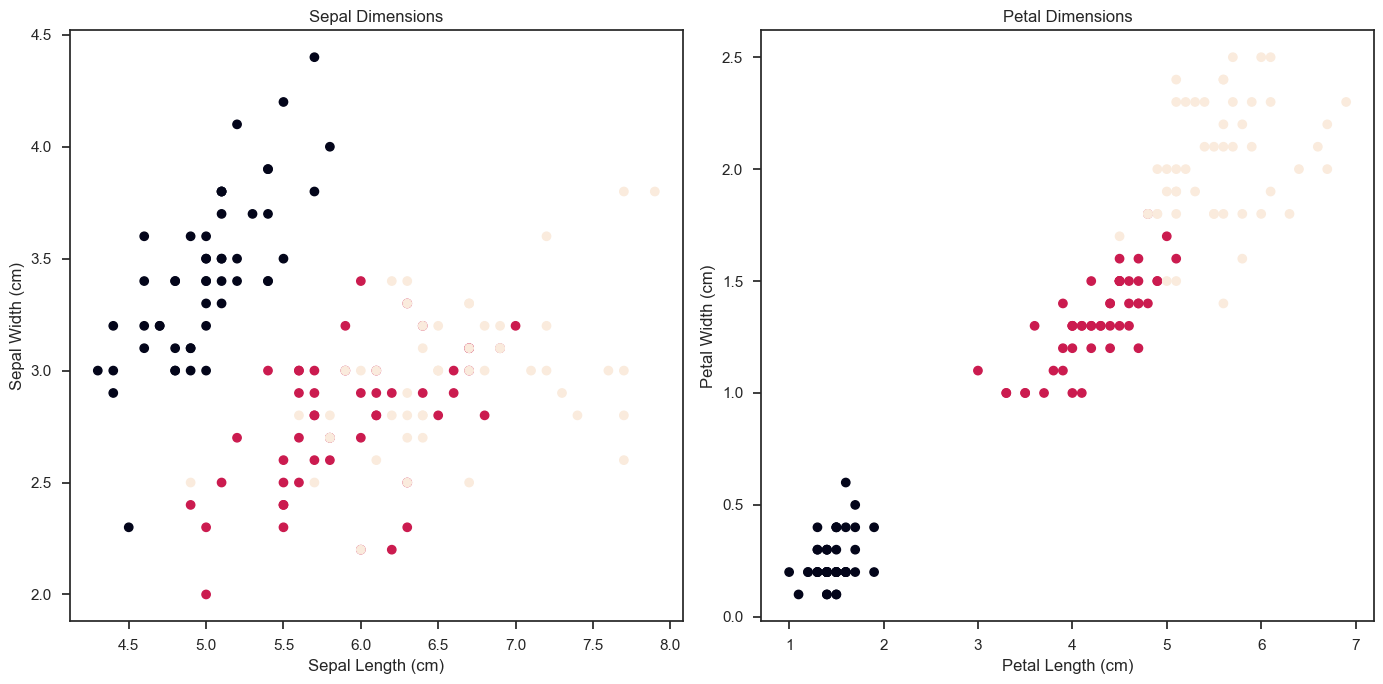

In [4]:
# Create subplots
plt.figure(figsize=(14, 7))

# Subplot 1: Scatter plot of Sepal Length vs. Sepal Width
plt.subplot(121)
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], c=data.target)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Dimensions')

# Subplot 2: Scatter plot of Petal Length vs. Petal Width
plt.subplot(122)
plt.scatter(iris_df['petal length (cm)'], iris_df['petal width (cm)'], c=data.target)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Dimensions')


plt.tight_layout()
plt.show()

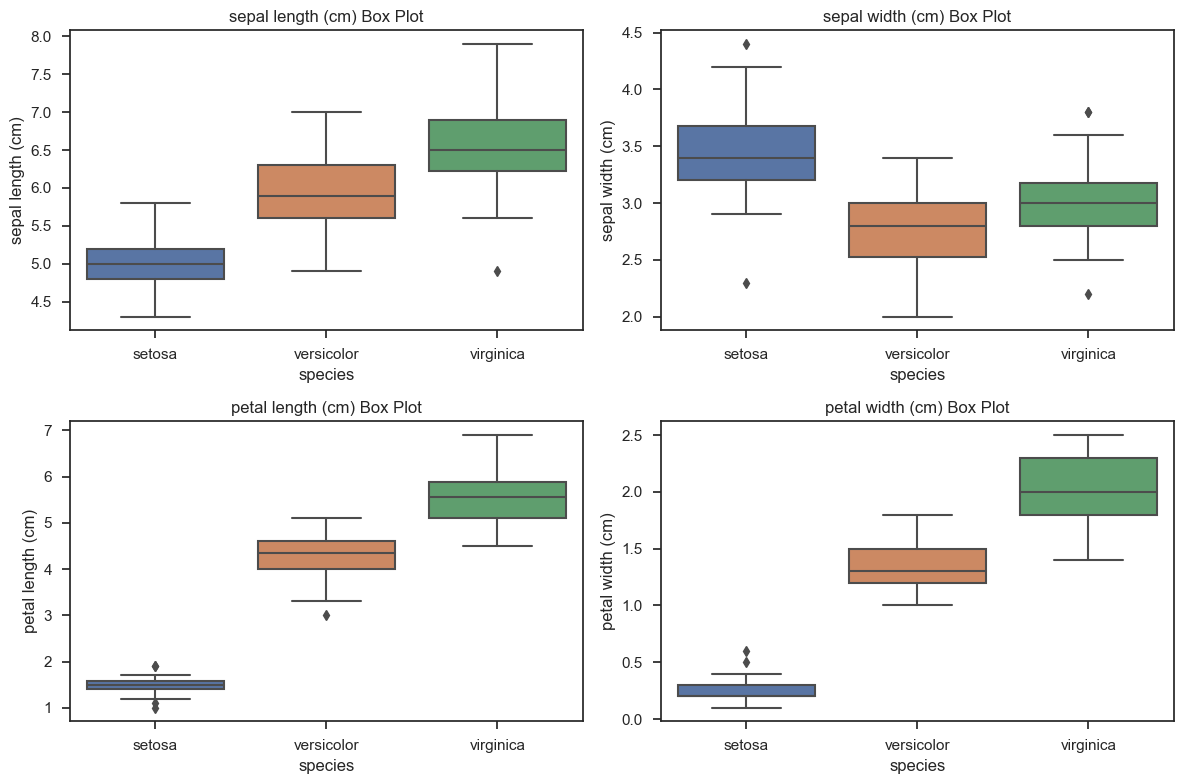

In [5]:
# Create box plots for each feature
plt.figure(figsize=(12, 8))  # Adjust the figure size as needed
for i, feature in enumerate(iris_df.columns[:-1]):  # Exclude the 'species' column
    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of subplots
    sns.boxplot(x='species', y=feature, data=iris_df)
    plt.title(f"{feature} Box Plot")
plt.tight_layout()
plt.show()

## Preprocessing

### Checking for Missing Values

Before applying K-Means clustering, it's essential to ensure that there are no missing values in the dataset, as K-Means cannot handle missing data. This step involves checking each feature for any missing values and addressing them if found.



In [6]:
# Checking for Missing Values
missing_values = iris_df.isnull().sum()
missing_values

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In the case of the Iris dataset, it is a well-curated dataset, and there are no missing values.

### Standardizing Feature Values
Standardizing the feature values is important for K-Means clustering since it's sensitive to the scale of the data. Standardization transforms the data such that each feature has a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally to the clustering process, regardless of their original scales. The standardization step is especially useful when the features have different units or orders of magnitude.

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
iris_df_scaled = scaler.fit_transform(iris_df.iloc[:, :-1])  # Exclude the 'species' column

## Clustering

Our  objective is to group similar data points together into clusters or segments based on their inherent characteristics or similarities, without the use of predefined labels.

In the case of the Iris dataset, we aim to identify natural groupings among iris flowers based on their four feature attributes: sepal length, sepal width, petal length, and petal width.

Clustering helps uncover patterns and structures within the data, potentially revealing distinct species or varieties of iris flowers based on these features.

### Choosing the Number of Clusters

Choosing the Number of Clusters is a critical step in K-Means clustering, as it determines how many groups or clusters the algorithm will divide the data into. We typically use techniques like the "`Elbow Method`" and "`Silhouette Analysis`" to make an informed choice for the number of clusters (K).


- **Elbow Method**: The Elbow Method involves running K-Means clustering for a range of `K` values and plotting the sum of squared distances (inertia) between data points and their assigned cluster centers as a function of `K`. The "elbow point" on the plot, where the inertia begins to level off, is typically chosen as the optimal `K`.


- **Silhouette Analysis**: Silhouette Analysis measures how similar each data point in one cluster is to the data points in the same cluster compared to the nearest neighboring cluster. The silhouette score varies from `-1` (a poor clustering) to `+1` (a perfect clustering). We aim to choose the `K` that yields the highest silhouette score.

- **Domain knowledge**: The common and often recommended number of clusters for the Iris dataset is 3. This choice is based on the nature of the Iris dataset, which consists of three distinct species of iris flowers: Setosa, Versicolor, and Virginica. Each species corresponds to a natural cluster, and the goal of clustering is often to identify these three species.


#### Elbow Method

C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

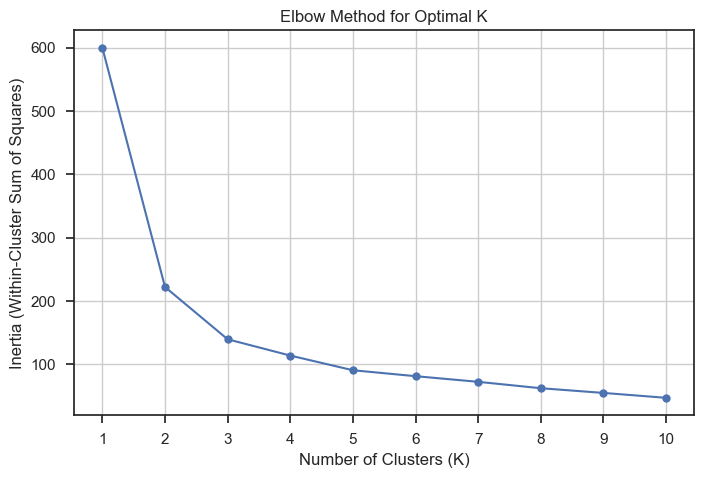

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize an empty list to store inertia (within-cluster sum of squares) for different K values
inertia = []

# Define a range of K values to test
k_range = range(1, 11)

# Perform K-Means clustering for each K and calculate inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(iris_df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()


#### Silhouette Analysis


C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

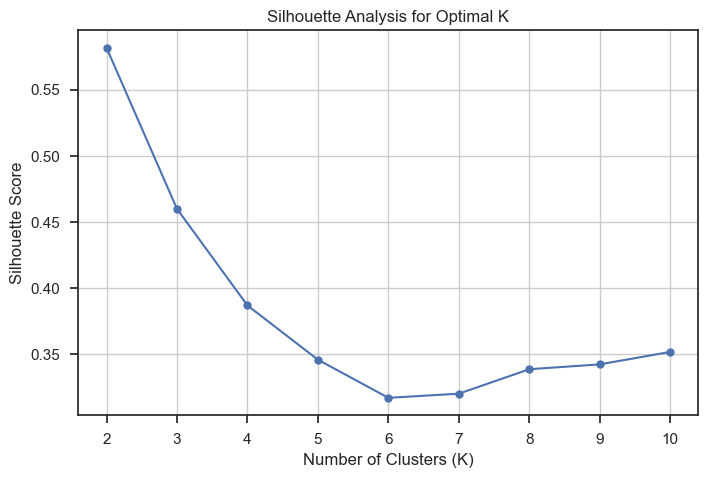

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Initialize an empty list to store Silhouette scores for different K values
silhouette_scores = []

# Define a range of K values to test
k_range = range(2, 11)

# Perform K-Means clustering for each K and calculate Silhouette score
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(iris_df_scaled)
    silhouette_avg = silhouette_score(iris_df_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot the Silhouette Analysis results
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()


#### Domain Knowledge

The common and often recommended number of clusters for the Iris dataset is 3. This choice is based on the nature of the Iris dataset, which consists of three distinct species of iris flowers: Setosa, Versicolor, and Virginica. Each species corresponds to a natural cluster, and the goal of clustering is often to identify these three species.

In [10]:
from sklearn.cluster import KMeans

# Create a K-Means instance with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the K-Means model to the standardized data
kmeans.fit(iris_df_scaled)

# Get cluster labels for each data point
cluster_labels = kmeans.labels_

# Add the cluster labels to the DataFrame
iris_df['cluster'] = cluster_labels

# Display the first few rows of the DataFrame with cluster labels
print(iris_df.head())

C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  cluster  
0  setosa        1  
1  setosa        1  
2  setosa        1  
3  setosa        1  
4  setosa        1  


## Clustering Results

### K-Means Algorithm

K-Means is a **partitioning clustering algorithm that aims to divide a dataset into K distinct, non-overlapping clusters**. It operates based on the principle of **minimizing the sum of squared distances between data points and their respective cluster centroids**. The algorithm iteratively assigns data points to the nearest cluster center and updates the centroids until convergence.


#### 1. Initialization:

- Select the number of clusters, `K`, to divide the dataset into.


- Initialize `K` cluster centroids randomly or using a predefined method.


#### 2. Assignment Step (Expectation):

- For each data point, calculate its distance to all `K` centroids.


- Assign the data point to the cluster associated with the nearest centroid.


#### 3. Update Step (Maximization):

- Recalculate the centroids of each cluster by taking the mean of all data points assigned to that cluster.



#### 4. Convergence Check:

- Repeat the assignment and update steps iteratively until one of the stopping criteria is met:
    - Centroids no longer change significantly.
    - A maximum number of iterations is reached.
    - Data points' assignments no longer change.


#### 5. Result:

- The algorithm produces `K` clusters, and each data point belongs to one of these clusters.


- The cluster centroids represent the mean of data points within each cluster.

We can visualize how Iris dataset was separated into clusters using scatter plots. We create scatter plots for pairs of features and color the data points by their cluster labels.

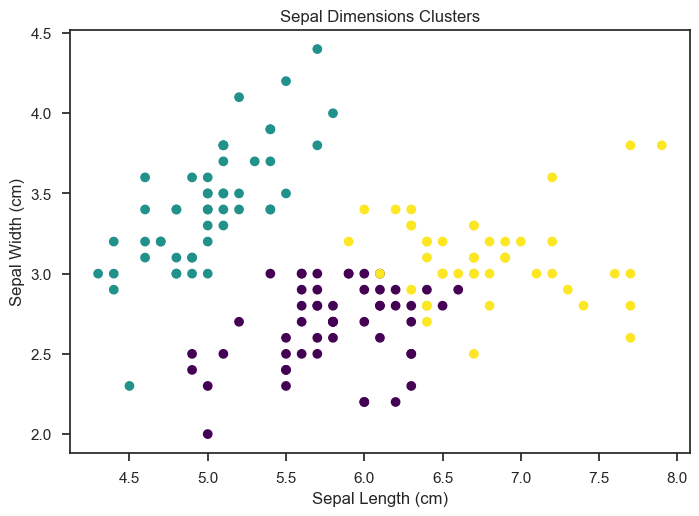

In [11]:
import matplotlib.pyplot as plt

# Scatter plot of Sepal Length vs. Sepal Width colored by cluster
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], c=cluster_labels, cmap='viridis')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Dimensions Clusters')
plt.show()


### Perform PCA and Visualize the Cluster Regions

Next, we visualize the results of clustering using the K-Means algorithm on 2D reduced-dimensional data obtained through Principal Component Analysis (PCA). 

The key steps involve reducing the data's dimensionality with PCA, fitting K-Means with 3 clusters to the reduced data, creating a mesh grid to cover the data space, predicting cluster assignments for grid points, plotting decision boundaries to show cluster borders, and scatter plotting the data points in 2D, color-coded by their cluster assignments. 

The visualization with decision boundaries helps understand the clustering results


C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\evisp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


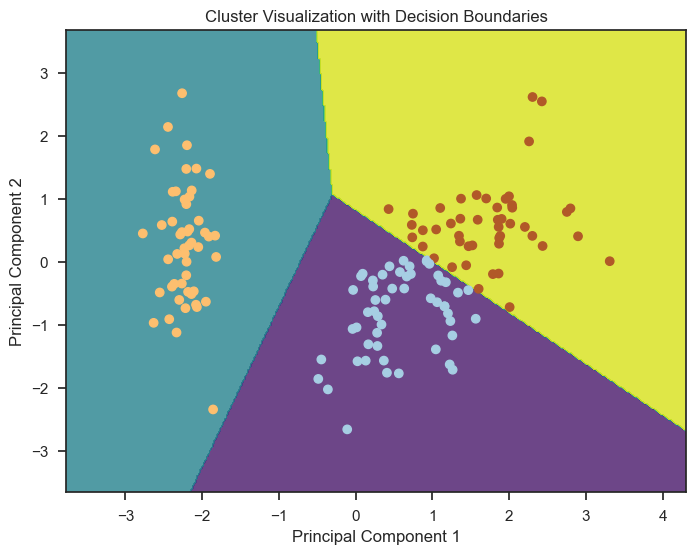

In [17]:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(iris_df_scaled)

# Fit K-Means on the reduced-dimensional data
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_reduced)

# Create a mesh grid
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict cluster assignments for points in the mesh grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.8)

# Scatter plot for data points colored by clusters
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=cluster_labels, cmap=plt.cm.Paired)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Cluster Visualization with Decision Boundaries')
plt.show()